# ML Homework 03: Linear Regression


## Описание

В этом задании вам предстоит реализовать линейную регрессию «с нуля», используя только библиотеку NumPy.
Вы научитесь:
1. Работать с матричными операциями для решения задачи минимизации ошибок.
2. Реализовывать аналитическое решение (Normal Equation).
3. Оценивать качество модели с помощью метрик MSE и $R^2$.

### Теория
Линейная регрессия моделирует зависимость между $X$ и $y$ как:
$$ y = Xw + \epsilon $$
Где $w$ — вектор весов (включая свободный член bias).

Аналитическое решение (OLS) находится по формуле:
$$ w = (X^T X)^{-1} X^T y $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLR, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import ipytest
import pytest

%matplotlib inline


## Часть 1: Подготовка данных и метрики

### Задание 1: Реализуйте Mean Squared Error (MSE)
$$ MSE = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 $$

###     Задание 2: Реализуйте R-squared ($R^2$)
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

In [2]:
def generate_synthetic_data(n_samples=100, n_features=1, noise=10, random_state=42):
    """
    Генерация синтетических данных для регрессии: y = Xw + b + noise
    """
    np.random.seed(random_state)
    X = 2 * np.random.rand(n_samples, n_features)
    true_w = np.random.randn(n_features, 1) * 10
    true_b = np.random.randn(1) * 5

    y = X.dot(true_w) + true_b + np.random.randn(n_samples, 1) * noise
    return X, y, true_w, true_b

def mse_metric(y_true, y_pred):
    """
    Задание 1: Реализуйте Mean Squared Error (MSE)
    $$ MSE = \frac{1}{N} \\sum_{i=1}^N (y_i - \\hat{y}_i)^2 $$
    """
    #TODO: Вычислите MSEа
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

def r2_metric(y_true, y_pred):
    """
    Задание 2: Реализуйте R-squared ($R^2$)
    $$ R^2 = 1 - \frac{\\sum (y_i - \\hat{y}_i)^2}{\\sum (y_i - \bar{y})^2} $$
    """
    #TODO: Вычислите R^2
    y_mean = np.mean(y_true)
    ss_res = np.sum((y_true-y_pred) ** 2)
    ss_tot = np.sum((y_true - y_mean) ** 2)

    if ss_tot == 0:
        return 0.0
    return 1 - ss_res/ss_tot

## Часть 2: Реализация класса LinearRegression

In [3]:
class MyLinearRegression:
    def __init__(self):
        self.weights = None # Включая bias как первый элемент или отдельно

    def fit(self, X, y):
        """
        Задание 3: Обучение модели методом наименьших квадратов (Normal Equation).

        Алгоритм:
        1. Добавить столбец единиц к X (для свободного члена bias).
        2. Вычислить веса по формуле: w = (X^T * X)^(-1) * X^T * y

        Подсказка: используйте np.hstack, np.linalg.inv (или pinv), .T, .dot (@)
        """
        #TODO: Реализовать аналитическое решение
        # X_b = ...
        # self.weights = ...
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])

        self.weights = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
    def predict(self, X):
        """
        Задание 4: Предсказание.

        Алгоритм:
        1. Добавить столбец единиц к X (если вы добавили его в веса).
        2. Вычислить y_pred = X_b * w
        """
        if self.weights is None:
            raise Exception("Model not fitted")

        #TODO: Реализовать предсказание
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])

        return X_b @ self.weights

## Часть 3: Сравнение и Визуализация

Здесь код уже написан, он нужен для проверки ваших функций визуально.

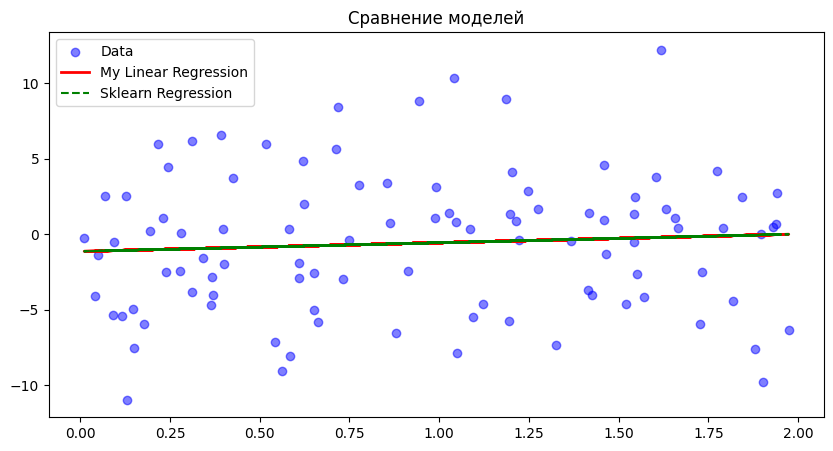

MSE (My): 21.0949
MSE (Sklearn): 21.0949
R2 (My): 0.0055


In [4]:
# Генерация данных
X, y, _, _ = generate_synthetic_data(n_samples=100, noise=5)

# 1. Ваша модель
my_model = MyLinearRegression()
my_model.fit(X, y)
y_pred_my = my_model.predict(X)

# 2. Sklearn модель (для проверки)
sk_model = SklearnLR()
sk_model.fit(X, y)
y_pred_sk = sk_model.predict(X)

# Визуализация
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data')
plt.plot(X, y_pred_my, color='red', linewidth=2, label='My Linear Regression')
plt.plot(X, y_pred_sk, color='green', linestyle='--', label='Sklearn Regression')
plt.legend()
plt.title("Сравнение моделей")
plt.show()

print(f"MSE (My): {mse_metric(y, y_pred_my):.4f}")
print(f"MSE (Sklearn): {mean_squared_error(y, y_pred_sk):.4f}")
print(f"R2 (My): {r2_metric(y, y_pred_my):.4f}")

## Тесты (ipytest)

In [5]:
ipytest.autoconfig()

class TestLinearRegression:

    @pytest.fixture
    def data(self):
        return generate_synthetic_data(n_samples=50, n_features=2, noise=1)

    def test_task1_mse(self):
        y_true = np.array([1, 2, 3])
        y_pred = np.array([1.1, 1.9, 3.2])
        # (0.01 + 0.01 + 0.04) / 3 = 0.06 / 3 = 0.02
        expected = np.mean((y_true - y_pred)**2)
        assert np.isclose(mse_metric(y_true, y_pred), expected), "Ошибка в формуле MSE"

    def test_task2_r2(self):
        y_true = np.array([1, 2, 3])
        y_pred = np.array([1, 2, 3])
        assert r2_metric(y_true, y_pred) == 1.0, "R2 для идеального предсказания должен быть 1"

        y_pred_bad = np.array([2, 2, 2]) # Mean model
        # R2 должен быть 0 (или близко к нему)
        assert np.isclose(r2_metric(y_true, y_pred_bad), 0.0), "R2 для среднего значения должен быть 0"

    def test_task3_fit_predict(self, data):
        X, y, _, _ = data
        model = MyLinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        assert y_pred.shape == (50, 1), "Неверная размерность предсказаний"
        assert model.weights is not None, "Веса не были инициализированы"

        # Сравнение с sklearn (допускается небольшая погрешность)
        sk_model = SklearnLR()
        sk_model.fit(X, y)
        sk_pred = sk_model.predict(X)

        mse_diff = abs(mean_squared_error(y, y_pred) - mean_squared_error(y, sk_pred))
        assert mse_diff < 1e-5, f"Ваша модель сильно отклоняется от эталона sklearn. Diff: {mse_diff}"

ipytest.run()

...                                                                                          [100%]
3 passed in 0.02s


<ExitCode.OK: 0>

## Часть 4: Регуляризация — Ridge и Lasso

Обычная линейная регрессия (OLS) минимизирует только ошибку на обучающих данных:
$$\hat{w} = \underset{w}{\arg\min}\; \|Xw - y\|^2$$

Регуляризация добавляет штраф за большие веса, что улучшает обобщение и стабилизирует решение.

---

### Ridge (L2-регуляризация)

$$\hat{w} = \underset{w}{\arg\min}\; \|Xw - y\|^2 + \alpha \|w\|_2^2$$

**Аналитическое решение:**
$$w = (X^TX + \alpha I)^{-1} X^T y$$

Слагаемое $\alpha I$ делает матрицу $X^TX$ обратимой даже при **мультиколлинеарности** — когда признаки сильно коррелируют между собой. В этом случае OLS даёт нестабильные и очень большие по норме веса, Ridge «сжимает» их к нулю, но не обнуляет.

---

### Lasso (L1-регуляризация)

$$\hat{w} = \underset{w}{\arg\min}\; \|Xw - y\|^2 + \alpha \|w\|_1$$

Замкнутой формулы нет — решается итеративно (coordinate descent). Lasso имеет свойство **sparsity**: при достаточно большом $\alpha$ часть коэффициентов становится в точности равна нулю. Это одновременно регуляризация и **отбор признаков**.

---

### Сравнение

| | Ridge | Lasso |
|---|---|---|
| Штраф | $\|w\|_2^2$ | $\|w\|_1$ |
| Обнуляет коэффициенты | Нет (только уменьшает) | Да |
| Отбор признаков | Нет | Да |
| Хорошо при | Мультиколлинеарности | Многих нерелевантных признаках |

Гиперпараметр $\alpha \geq 0$ контролирует силу регуляризации: при $\alpha = 0$ — обычный OLS.


### Задание 5: Ridge при мультиколлинеарности

Ниже сгенерированы данные, в которых несколько признаков являются почти линейными комбинациями друг друга (мультиколлинеарность). Обычная линейная регрессия на таких данных даёт нестабильные веса и плохую обобщаемость.

**Ваши задачи:**
1. Обучить `LinearRegression` и `Ridge` с каждым значением из `alphas`.
2. Для каждой модели вычислить MSE на **тестовой** выборке (`X_test_s`, `y_test`).
3. Вывести результаты (например, таблицей или `print`).

Готовый код ниже построит график — по нему будет видно, при какой alpha Ridge выигрывает у OLS.


In [6]:
def generate_collinear_data(n_samples=200, n_base=5, n_collinear=5, noise=5.0, random_state=42):
    """
    Генерирует данные с мультиколлинеарностью.
    n_base базовых признаков + n_collinear признаков, которые являются почти
    линейными комбинациями базовых (с небольшим шумом).
    """
    rng = np.random.default_rng(random_state)
    X_base = rng.standard_normal((n_samples, n_base))
    # Коллинеарные признаки = линейная комбинация базовых + малый шум
    coeffs = rng.standard_normal((n_base, n_collinear))
    X_collinear = X_base @ coeffs + rng.standard_normal((n_samples, n_collinear)) * 0.05
    X = np.hstack([X_base, X_collinear])

    true_w = rng.standard_normal(n_base + n_collinear)
    y = X @ true_w + rng.standard_normal(n_samples) * noise

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_test_s, y_train, y_test

X_train_s, X_test_s, y_train_ridge, y_test_ridge = generate_collinear_data()
print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")


Train: (140, 10), Test: (60, 10)


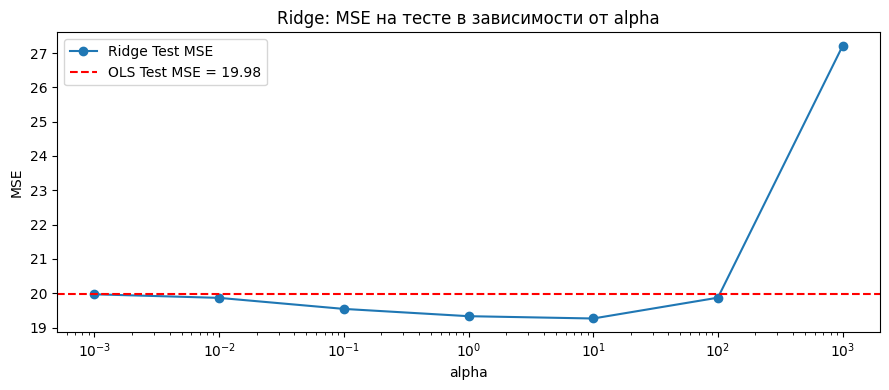

OLS Test MSE:   19.9846
Ridge alpha=0.001    Test MSE: 19.9698
Ridge alpha=0.01     Test MSE: 19.8654
Ridge alpha=0.1      Test MSE: 19.5439
Ridge alpha=1.0      Test MSE: 19.3316
Ridge alpha=10.0     Test MSE: 19.2643
Ridge alpha=100.0    Test MSE: 19.8710
Ridge alpha=1000.0   Test MSE: 27.2062


In [ ]:
from sklearn.linear_model import LinearRegression
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

#TODO: Обучите LinearRegression на (X_train_s, y_train_ridge)
#       и вычислите его MSE на (X_test_s, y_test_ridge).
#       Сохраните результат в переменную ols_test_mse.
ols_model = LinearRegression().fit(X_train_s, y_train_ridge)

y_pred_ols = ols_model.predict(X_test_s)
ols_test_mse = mean_squared_error(y_test_ridge, y_pred_ols) # ← замените на реальное значение


#TODO: Для каждого alpha из списка alphas:
#       - обучите Ridge(alpha=alpha) на (X_train_s, y_train_ridge)
#       - вычислите MSE на (X_test_s, y_test_ridge)
#       - добавьте результат в список ridge_test_mses
ridge_test_mses = [
    mean_squared_error(
        y_test_ridge,
        Ridge(alpha=alpha).fit(X_train_s, y_train_ridge).predict(X_test_s)
    )
    for alpha in alphas
]  # ← замените на реальные значения


# --- Готовый код визуализации (не изменяйте) ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, ridge_test_mses, marker='o', label='Ridge Test MSE')
ax.axhline(ols_test_mse, color='red', linestyle='--', label=f'OLS Test MSE = {ols_test_mse:.2f}')
ax.set_xlabel('alpha')
ax.set_ylabel('MSE')
ax.set_title('Ridge: MSE на тесте в зависимости от alpha')
ax.legend()
plt.tight_layout()
plt.show()

print(f"OLS Test MSE:   {ols_test_mse:.4f}")
for a, m in zip(alphas, ridge_test_mses):
    print(f"Ridge alpha={a:<8} Test MSE: {m:.4f}")


### Задание 6: Lasso и feature importance

Ниже сгенерированы данные с 15 признаками, из которых **только 3 информативных** — остальные 12 являются чистым шумом. Lasso при достаточном $\alpha$ должен сам найти эти три признака, обнуляя остальные коэффициенты.

**Ваши задачи:**
1. Обучить `Lasso` с каждым значением из `alphas`.
2. Для каждой модели вычислить MSE на **тестовой** выборке и количество **ненулевых** коэффициентов.
3. Вывести для лучшей модели (наименьший test MSE) **feature importances** — значения коэффициентов `model.coef_` (сохраните в переменную `best_coef`).

Готовый код ниже построит bar-chart коэффициентов и отметит настоящие информативные признаки.


In [8]:
def generate_sparse_data(n_samples=300, n_features=15, n_informative=3, noise=3.0, random_state=42):
    """
    Генерирует данные, где только n_informative признаков из n_features имеют
    ненулевые веса (остальные — шум). Возвращает также истинные информативные индексы.
    """
    rng = np.random.default_rng(random_state)
    X = rng.standard_normal((n_samples, n_features))
    informative_idx = rng.choice(n_features, size=n_informative, replace=False)
    true_w = np.zeros(n_features)
    true_w[informative_idx] = rng.standard_normal(n_informative) * 5
    y = X @ true_w + rng.standard_normal(n_samples) * noise

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_test_s, y_train, y_test, informative_idx

N_FEATURES_LASSO = 15
X_train_l, X_test_l, y_train_lasso, y_test_lasso, informative_idx = generate_sparse_data(
    n_features=N_FEATURES_LASSO
)
feature_names = [f"x{i}" for i in range(N_FEATURES_LASSO)]
print(f"Train: {X_train_l.shape}, Test: {X_test_l.shape}")
print(f"Информативные признаки: {[feature_names[i] for i in informative_idx]}")


Train: (210, 15), Test: (90, 15)
Информативные признаки: ['x9', 'x4', 'x14']


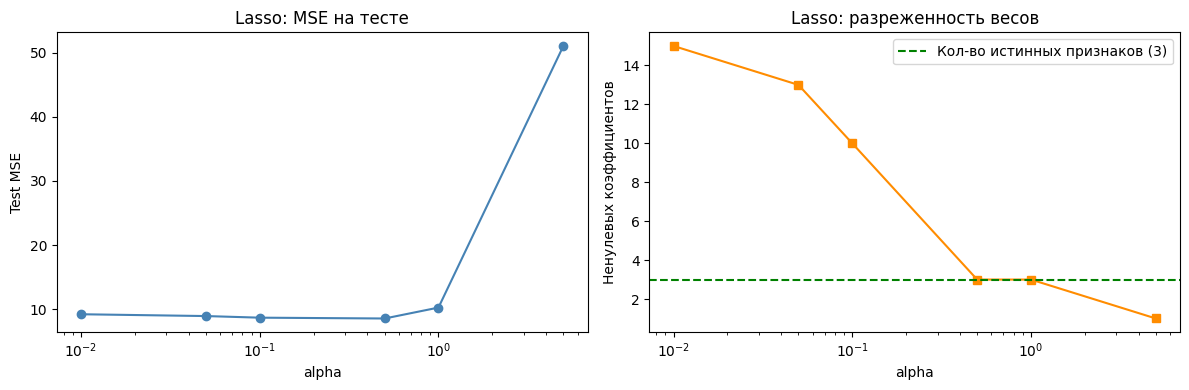

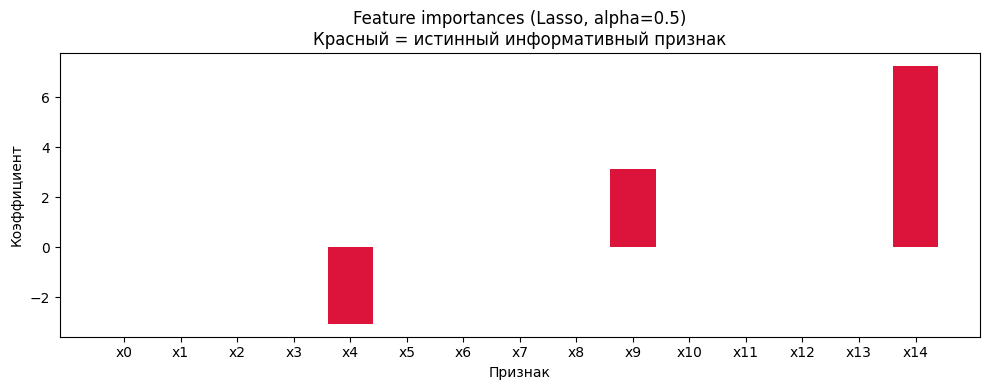


Лучшая alpha: 0.5
Test MSE: 8.5444
Ненулевых коэффициентов: 3 / 15

Feature importances (best model):
  x0: -0.0000
  x1: -0.0000
  x2: +0.0000
  x3: -0.0000
  x4: -3.0638 ← истинный
  x5: -0.0000
  x6: +0.0000
  x7: -0.0000
  x8: -0.0000
  x9: +3.1463 ← истинный
  x10: -0.0000
  x11: +0.0000
  x12: +0.0000
  x13: -0.0000
  x14: +7.2582 ← истинный


In [11]:
lasso_alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

#TODO: Для каждого alpha из lasso_alphas:
#       - обучите Lasso(alpha=alpha, max_iter=10000) на (X_train_l, y_train_lasso)
#       - вычислите MSE на (X_test_l, y_test_lasso)
#       - подсчитайте количество ненулевых коэффициентов: np.sum(model.coef_ != 0)
#       - добавьте значения в соответствующие списки
lasso_test_mses = []   # ← замените
lasso_nonzero  = [] # ← замените 
models = []  
for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=10000).fit(X_train_l, y_train_lasso)
    models.append(model)
    lasso_test_mses.append(mean_squared_error(y_test_lasso, model.predict(X_test_l)))
    lasso_nonzero.append(int(np.sum(model.coef_ != 0)))
#TODO: Найдите индекс лучшей модели (наименьший test MSE)
#       и сохраните её коэффициенты в best_coef (массив длины N_FEATURES_LASSO).
best_alpha_idx = np.argmin(lasso_test_mses)                                 # ← замените
best_coef = models[best_alpha_idx].coef_.copy()               # ← замените


# --- Готовый код визуализации (не изменяйте) ---

# График 1: MSE и число ненулевых коэффициентов vs alpha
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogx(lasso_alphas, lasso_test_mses, marker='o', color='steelblue')
ax1.set_xlabel('alpha'); ax1.set_ylabel('Test MSE')
ax1.set_title('Lasso: MSE на тесте')

ax2.semilogx(lasso_alphas, lasso_nonzero, marker='s', color='darkorange')
ax2.axhline(3, color='green', linestyle='--', label='Кол-во истинных признаков (3)')
ax2.set_xlabel('alpha'); ax2.set_ylabel('Ненулевых коэффициентов')
ax2.set_title('Lasso: разреженность весов')
ax2.legend()
plt.tight_layout(); plt.show()

# График 2: Feature importances лучшей модели
colors = ['crimson' if i in informative_idx else 'steelblue' for i in range(N_FEATURES_LASSO)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(feature_names, best_coef, color=colors)
ax.set_xlabel('Признак'); ax.set_ylabel('Коэффициент')
ax.set_title(f'Feature importances (Lasso, alpha={lasso_alphas[best_alpha_idx]})\n'
             f'Красный = истинный информативный признак')
plt.tight_layout(); plt.show()

print(f"\nЛучшая alpha: {lasso_alphas[best_alpha_idx]}")
print(f"Test MSE: {lasso_test_mses[best_alpha_idx]:.4f}")
print(f"Ненулевых коэффициентов: {lasso_nonzero[best_alpha_idx]} / {N_FEATURES_LASSO}")
print("\nFeature importances (best model):")
for name, coef in zip(feature_names, best_coef):
    marker = " ← истинный" if feature_names.index(name) in informative_idx else ""
    print(f"  {name}: {coef:+.4f}{marker}")


## Тесты — Часть 4


In [12]:
class TestRegularization:

    @pytest.fixture
    def collinear(self):
        return generate_collinear_data()

    @pytest.fixture
    def sparse(self):
        return generate_sparse_data(n_features=N_FEATURES_LASSO)

    # --- Задание 5: Ridge ---

    def test_task5_ridge_better_than_ols(self, collinear):
        """Ridge с хорошей alpha должен давать меньший test MSE, чем обычный OLS."""
        X_tr, X_te, y_tr, y_te = collinear

        ols = SklearnLR().fit(X_tr, y_tr)
        ols_mse = mean_squared_error(y_te, ols.predict(X_te))

        # Хотя бы одна alpha из списка должна улучшать OLS
        ridge_mses = [
            mean_squared_error(y_te, Ridge(alpha=a).fit(X_tr, y_tr).predict(X_te))
            for a in [0.1, 1.0, 10.0, 100.0, 1000.0]
        ]
        assert any(m < ols_mse for m in ridge_mses), (
            f"Ни один Ridge не улучшил OLS (OLS MSE={ols_mse:.4f}, "
            f"лучший Ridge MSE={min(ridge_mses):.4f}). "
            "Проверьте, что вы правильно передаёте train/test данные."
        )

    def test_task5_ridge_result_variables(self):
        """Переменные ols_test_mse и ridge_test_mses должны быть заполнены."""
        assert ols_test_mse > 0, "ols_test_mse не вычислен (равен 0)"
        assert any(m > 0 for m in ridge_test_mses), "ridge_test_mses не заполнен"
        assert len(ridge_test_mses) == len(alphas), "Длина ridge_test_mses не совпадает с alphas"

    # --- Задание 6: Lasso ---

    def test_task6_lasso_sparsity(self, sparse):
        """При alpha=1.0 Lasso должен обнулить большинство из 15 признаков."""
        X_tr, X_te, y_tr, y_te, _ = sparse
        model = Lasso(alpha=1.0, max_iter=10000).fit(X_tr, y_tr)
        nonzero = int(np.sum(model.coef_ != 0))
        assert nonzero <= N_FEATURES_LASSO // 2, (
            f"При alpha=1.0 Lasso оставил {nonzero} ненулевых коэффициентов из {N_FEATURES_LASSO}. "
            "Ожидалось не более половины — убедитесь, что данные стандартизированы."
        )

    def test_task6_best_coef_shape(self):
        """best_coef должен быть массивом длины N_FEATURES_LASSO."""
        assert hasattr(best_coef, '__len__'), "best_coef должен быть массивом"
        assert len(best_coef) == N_FEATURES_LASSO, (
            f"Длина best_coef={len(best_coef)}, ожидается {N_FEATURES_LASSO}"
        )

    def test_task6_informative_features_nonzero(self):
        """Коэффициенты настоящих информативных признаков должны быть ненулевыми в best_coef."""
        zero_informative = [i for i in informative_idx if best_coef[i] == 0]
        assert len(zero_informative) == 0, (
            f"Lasso обнулил информативные признаки {zero_informative}. "
            "Попробуйте выбрать меньшую alpha для best_alpha_idx."
        )

ipytest.run()


........                                                                                     [100%]
8 passed in 0.05s


<ExitCode.OK: 0>